In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/clean_data.csv')

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (184327, 10)
Columns: ['Voltage', 'Power_Factor', 'Power', 'ESP32_Temperature', 'CPU_Consumption', 'CPU_Power_Consumption', 'CPU_Temperature', 'RAM_Consumption', 'RAM_Power_Consumption', 'RAM_Temperature']


,Voltage,Power_Factor,Power,ESP32_Temperature,CPU_Consumption,CPU_Power_Consumption,CPU_Temperature,RAM_Consumption,RAM_Power_Consumption,RAM_Temperature
0,120.006557,0.968525,101.468852,0.873279,0.0,0.0,0.0,0.0,0.0,0.0
1,120.006557,0.972787,102.250820,0.876230,0.0,0.0,0.0,0.0,0.0,0.0
2,120.037705,0.958689,100.242623,0.870328,0.0,0.0,0.0,0.0,0.0,0.0
3,120.027869,0.944262,98.113115,0.865246,0.0,0.0,0.0,0.0,0.0,0.0
4,120.037705,0.943115,97.857377,0.863115,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# ================================================
# PREPROCESSING PIPELINE
# ================================================

X = df.drop(columns=['Power'])
y = df['Power']

print("Step 1 - Features and target defined")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nStep 2 - Train/Test Split")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nStep 3 - Feature Scaling applied (StandardScaler)")

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(y < lower) | (y > upper)]

print(f"\nStep 4 - Outlier Detection")
print(f"Lower bound: {lower:.2f} Watts")
print(f"Upper bound: {upper:.2f} Watts")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier percentage: {len(outliers)/len(df)*100:.2f}%")

print("\nPreprocessing pipeline complete")

Step 1 - Features and target defined
Features shape: (184327, 9)
Target shape: (184327,)

Step 2 - Train/Test Split
Training set: (147461, 9)
Testing set: (36866, 9)

Step 3 - Feature Scaling applied (StandardScaler)

Step 4 - Outlier Detection
Lower bound: 46.02 Watts
Upper bound: 128.92 Watts
Number of outliers: 12325
Outlier percentage: 6.69%

Preprocessing pipeline complete


In [3]:
# ================================================
# FEATURE ENGINEERING - PROPOSED METHOD
# ================================================

df_fe = df.copy()


df_fe['CPU_Total_Load'] = df_fe['CPU_Consumption'] * df_fe['CPU_Power_Consumption']


df_fe['RAM_Total_Load'] = df_fe['RAM_Consumption'] * df_fe['RAM_Power_Consumption']


df_fe['Thermal_Stress'] = (df_fe['CPU_Temperature'] + df_fe['RAM_Temperature']) / 2


df_fe['Power_Efficiency'] = df_fe['Voltage'] * df_fe['Power_Factor']


df_fe['System_Load'] = (df_fe['CPU_Consumption'] + df_fe['RAM_Consumption']) / 2

print("=== Feature Engineering Complete ===")
print(f"Original features: {df.shape[1]-1}")
print(f"New features added: 5")
print(f"Total features now: {df_fe.shape[1]-1}")
print(f"\nNew features:")
print("1. CPU_Total_Load = CPU_Consumption × CPU_Power_Consumption")
print("2. RAM_Total_Load = RAM_Consumption × RAM_Power_Consumption")
print("3. Thermal_Stress = (CPU_Temp + RAM_Temp) / 2")
print("4. Power_Efficiency = Voltage × Power_Factor")
print("5. System_Load = (CPU_Consumption + RAM_Consumption) / 2")


new_features = ['CPU_Total_Load', 'RAM_Total_Load', 
                'Thermal_Stress', 'Power_Efficiency', 'System_Load']

print("\n=== New Feature Correlations with Power ===")
for f in new_features:
    corr = df_fe[f].corr(df_fe['Power'])
    print(f"{f}: {corr:.4f}")

=== Feature Engineering Complete ===
Original features: 9
New features added: 5
Total features now: 14

New features:
1. CPU_Total_Load = CPU_Consumption × CPU_Power_Consumption
2. RAM_Total_Load = RAM_Consumption × RAM_Power_Consumption
3. Thermal_Stress = (CPU_Temp + RAM_Temp) / 2
4. Power_Efficiency = Voltage × Power_Factor
5. System_Load = (CPU_Consumption + RAM_Consumption) / 2

=== New Feature Correlations with Power ===
CPU_Total_Load: 0.4340
RAM_Total_Load: 0.4317
Thermal_Stress: 0.4520
Power_Efficiency: 0.9892
System_Load: -0.0279


In [4]:
# ================================================
# PROPOSED METHOD - RF WITH FEATURE ENGINEERING
# ================================================


df_fe = df_fe.drop(columns=['System_Load'])


X_fe = df_fe.drop(columns=['Power'])
y_fe = df_fe['Power']


X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42)

print("New feature set shape:", X_fe_train.shape)
print("Features:", list(X_fe.columns))


print("\nTraining proposed method...")
rf_fe = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)
rf_fe.fit(X_fe_train, y_fe_train)
rf_fe_pred = rf_fe.predict(X_fe_test)


rf_fe_mse = mean_squared_error(y_fe_test, rf_fe_pred)
rf_fe_rmse = np.sqrt(rf_fe_mse)
rf_fe_mae = mean_absolute_error(y_fe_test, rf_fe_pred)
rf_fe_r2 = r2_score(y_fe_test, rf_fe_pred)

print("\n=== PROPOSED METHOD RESULTS ===")
print(f"MSE:  {rf_fe_mse:.4f}")
print(f"RMSE: {rf_fe_rmse:.4f}")
print(f"MAE:  {rf_fe_mae:.4f}")
print(f"R²:   {rf_fe_r2:.4f}")

New feature set shape: (147461, 13)
Features: ['Voltage', 'Power_Factor', 'ESP32_Temperature', 'CPU_Consumption', 'CPU_Power_Consumption', 'CPU_Temperature', 'RAM_Consumption', 'RAM_Power_Consumption', 'RAM_Temperature', 'CPU_Total_Load', 'RAM_Total_Load', 'Thermal_Stress', 'Power_Efficiency']

Training proposed method...

=== PROPOSED METHOD RESULTS ===
MSE:  0.0166
RMSE: 0.1290
MAE:  0.0603
R²:   1.0000


FULL MODEL COMPARISON
            Model    MSE   RMSE    MAE     R2
Linear Regression 1.3376 1.1566 0.7303 0.9979
    Random Forest 0.0187 0.1366 0.0608 1.0000
          XGBoost 0.0847 0.2910 0.1081 0.9999
  Proposed Method 0.0166 0.1290 0.0603 1.0000


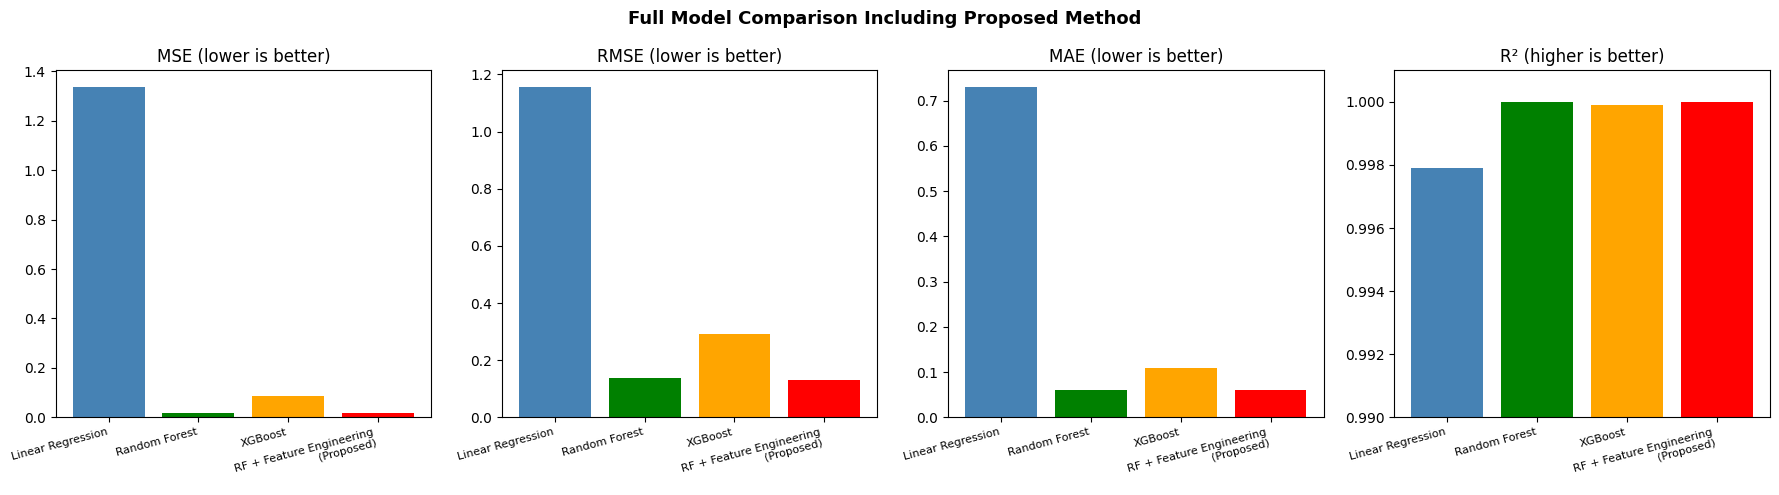


 Full comparison saved


In [5]:
# ================================================
# FULL COMPARISON - ALL MODELS
# ================================================

models = ['Linear Regression', 'Random Forest', 
          'XGBoost', 'RF + Feature Engineering\n(Proposed)']

mse_scores =  [1.3376, 0.0187, 0.0847, 0.0166]
rmse_scores = [1.1566, 0.1366, 0.2910, 0.1290]
mae_scores =  [0.7303, 0.0608, 0.1081, 0.0603]
r2_scores =   [0.9979, 1.0000, 0.9999, 1.0000]

print("="*65)
print("FULL MODEL COMPARISON")
print("="*65)
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 
              'XGBoost', 'Proposed Method'],
    'MSE':  [1.3376, 0.0187, 0.0847, 0.0166],
    'RMSE': [1.1566, 0.1366, 0.2910, 0.1290],
    'MAE':  [0.7303, 0.0608, 0.1081, 0.0603],
    'R2':   [0.9979, 1.0000, 0.9999, 1.0000]
})
print(comparison.to_string(index=False))


comparison.to_csv('../results/full_comparison.csv', index=False)


fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colors = ['steelblue', 'green', 'orange', 'red']

axes[0].bar(models, mse_scores, color=colors)
axes[0].set_title('MSE (lower is better)')
axes[0].set_xticklabels(models, rotation=15, ha='right', fontsize=8)

axes[1].bar(models, rmse_scores, color=colors)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xticklabels(models, rotation=15, ha='right', fontsize=8)

axes[2].bar(models, mae_scores, color=colors)
axes[2].set_title('MAE (lower is better)')
axes[2].set_xticklabels(models, rotation=15, ha='right', fontsize=8)

axes[3].bar(models, r2_scores, color=colors)
axes[3].set_title('R² (higher is better)')
axes[3].set_xticklabels(models, rotation=15, ha='right', fontsize=8)
axes[3].set_ylim([0.99, 1.001])

plt.suptitle('Full Model Comparison Including Proposed Method', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/full_comparison.png', dpi=150)
plt.show()

print("\n Full comparison saved")

=== Feature Importance (Proposed Method) ===
              Feature  Importance
              Voltage    0.609152
     Power_Efficiency    0.245906
         Power_Factor    0.124024
    ESP32_Temperature    0.020839
       CPU_Total_Load    0.000044
      CPU_Temperature    0.000008
CPU_Power_Consumption    0.000007
       Thermal_Stress    0.000007
      CPU_Consumption    0.000003
      RAM_Temperature    0.000003
      RAM_Consumption    0.000002
       RAM_Total_Load    0.000002
RAM_Power_Consumption    0.000002


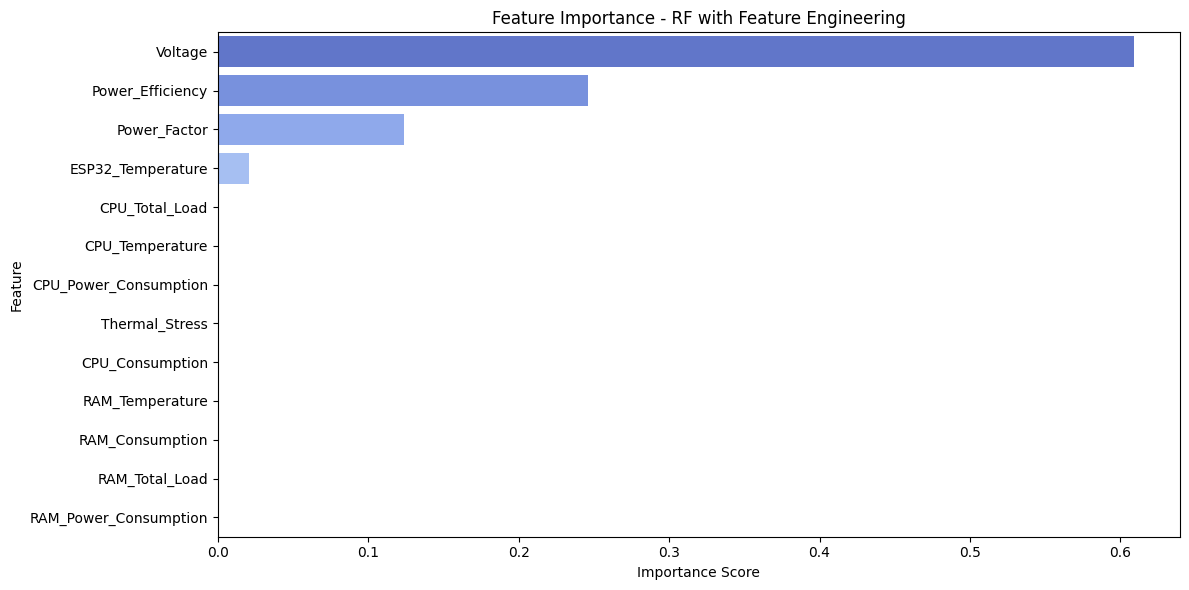


 Feature importance saved


In [6]:
# ================================================
# FEATURE IMPORTANCE - PROPOSED METHOD
# ================================================

feature_importance = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': rf_fe.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== Feature Importance (Proposed Method) ===")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, 
            x='Importance', 
            y='Feature', 
            palette='coolwarm')
plt.title('Feature Importance - RF with Feature Engineering')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150)
plt.show()

print("\n Feature importance saved")